# Time series classification and clustering



In [1]:
import sys

# Install dependencies if the notebook is running in Colab
if 'google.colab' in sys.modules:
    !pip install -U -qq reservoir_computing tsa_course tck dtaidistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 31.1 MB/s eta 0:00:00


In [2]:
!pip install -U -qq reservoir_computing tsa_course tck dtaidistance

In [3]:
# Imports
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, f1_score, v_measure_score, pairwise_kernels, pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.decomposition import KernelPCA
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import scipy.spatial.distance as ssd
import statsmodels.api as sm
from dtaidistance import dtw, dtw_ndim
from dtaidistance import dtw_visualisation as dtwvis
from tck.TCK import TCK
from tck.datasets import DataLoader
from reservoir_computing.reservoir import Reservoir
from reservoir_computing.tensorPCA import tensorPCA
from reservoir_computing.modules import RC_model
from reservoir_computing.utils import compute_test_scores

## Упражнения
Мы рассмотрим набор данных Libras. Набор данных содержит 15 классов по 24 экземпляра в каждом. Каждый класс ссылается на тип движения руки в LIBRAS (португальское название «LÍngua BRAsileira de Sinais», официальный бразильский язык сигналов).

In [4]:
Xtr, Ytr, Xte, Yte = DataLoader().get_data('Libras')

Loaded Libras dataset.
Number of classes: 15
Data shapes:
  Xtr: (180, 45, 2)
  Ytr: (180, 1)
  Xte: (180, 45, 2)
  Yte: (180, 1)


### Упражнение 1

1. Вычислите матрицу расстояний DTW.
2. Получите из нее матрицу сходства.
3. Постройте две матрицы. Прокомментируйте структуру, которую вы видите (не забудьте отсортировать элементы по классам).
4. Выполните классификацию с помощью классификаторов SVC и $k$-NN и сообщите:
- время обучения и тестирования,
- точность и оценку F1 на тестовом наборе.
5. Выполните иерархическую кластеризацию с помощью алгоритма Linkage Ward.
6. Постройте дендрограмму и проверьте ее, чтобы выбрать оптимальный порог для генерации кластерного раздела. Сообщите NMI для найденного вами раздела.
7. Выполните снижение размерности с помощью KernelPCA. Постройте результаты на двумерном графике.

In [5]:
# Общая подготовка для упражнений
from time import perf_counter
from IPython.display import display
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

y_tr = Ytr.ravel()
y_te = Yte.ravel()
y_all = np.concatenate([y_tr, y_te])
X_all = np.concatenate([Xtr, Xte], axis=0)

n_tr = len(y_tr)
n_classes = len(np.unique(y_all))
print(f"Libras: train={Xtr.shape}, test={Xte.shape}, классов={n_classes}")

Libras: train=(180, 45, 2), test=(180, 45, 2), классов=15


In [6]:
# Вспомогательные функции для матриц, классификации, кластеризации и KernelPCA

def similarity_from_distance(D):
    D = np.asarray(D, dtype=float)
    max_distance = np.nanmax(D)
    if max_distance <= 0:
        return np.ones_like(D)
    S = 1.0 - D / max_distance
    return np.clip(S, 0.0, 1.0)


def dissimilarity_from_similarity(S):
    S = np.asarray(S, dtype=float)
    max_similarity = np.nanmax(S)
    if max_similarity <= 0:
        return np.ones_like(S)
    D = 1.0 - S / max_similarity
    return np.clip(D, 0.0, None)


def clean_square_matrix(M, diagonal=None):
    M = np.asarray(M, dtype=float)
    M = 0.5 * (M + M.T)
    if diagonal is not None:
        np.fill_diagonal(M, diagonal)
    return M


def plot_sorted_matrix(M, y, title, cmap='viridis'):
    order = np.argsort(y)
    M_sorted = M[order][:, order]
    plt.figure(figsize=(5.5, 4.6))
    plt.imshow(M_sorted, aspect='auto', cmap=cmap)
    plt.title(title)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def split_train_test_matrices(M_all):
    return M_all[:n_tr, :n_tr], M_all[n_tr:, :n_tr]


def evaluate_precomputed_classifiers(name, K_train, K_test, D_train, D_test, k=3):
    D_train = np.maximum(D_train, 0.0)
    D_test = np.maximum(D_test, 0.0)
    np.fill_diagonal(D_train, 0.0)

    rows = []

    svc = svm.SVC(kernel='precomputed', C=1.0)
    start = perf_counter()
    svc.fit(K_train, y_tr)
    train_time = perf_counter() - start
    start = perf_counter()
    svc_pred = svc.predict(K_test)
    test_time = perf_counter() - start
    rows.append({
        'classifier': 'SVC',
        'train_time_s': train_time,
        'test_time_s': test_time,
        'accuracy': accuracy_score(y_te, svc_pred),
        'f1_macro': f1_score(y_te, svc_pred, average='macro'),
    })

    knn = KNeighborsClassifier(n_neighbors=k, metric='precomputed')
    start = perf_counter()
    knn.fit(D_train, y_tr)
    train_time = perf_counter() - start
    start = perf_counter()
    knn_pred = knn.predict(D_test)
    test_time = perf_counter() - start
    rows.append({
        'classifier': f'{k}-NN',
        'train_time_s': train_time,
        'test_time_s': test_time,
        'accuracy': accuracy_score(y_te, knn_pred),
        'f1_macro': f1_score(y_te, knn_pred, average='macro'),
    })

    report = pd.DataFrame(rows).set_index('classifier')
    print(name)
    display(report.round(4))
    return report


def ward_threshold_for_n_clusters(Z, n_obs, n_clusters):
    lower_idx = n_obs - n_clusters - 1
    upper_idx = n_obs - n_clusters
    if lower_idx < 0:
        return 0.0
    if upper_idx >= len(Z):
        return Z[-1, 2] + 1e-9
    return 0.5 * (Z[lower_idx, 2] + Z[upper_idx, 2])


def cluster_with_ward(name, D_all, y, n_clusters):
    D_all = clean_square_matrix(np.maximum(D_all, 0.0), diagonal=0.0)
    condensed = ssd.squareform(D_all, checks=False)
    Z = linkage(condensed, method='ward')
    threshold = ward_threshold_for_n_clusters(Z, len(y), n_clusters)
    clusters = fcluster(Z, t=threshold, criterion='distance')

    if len(np.unique(clusters)) != n_clusters:
        clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
        cut_info = f'maxclust={n_clusters}'
    else:
        cut_info = f'threshold={threshold:.4f}'

    plt.figure(figsize=(11, 4))
    dendrogram(Z, no_labels=True, color_threshold=threshold)
    plt.title(f'{name}: Ward dendrogram')
    plt.tight_layout()
    plt.show()

    nmi = normalized_mutual_info_score(y, clusters)
    print(f'{name}: clusters={len(np.unique(clusters))}, {cut_info}, NMI={nmi:.3f}')
    return Z, clusters, nmi


def plot_kernel_pca(name, K_all, y):
    K_all = clean_square_matrix(K_all)
    kpca = KernelPCA(n_components=2, kernel='precomputed', random_state=RANDOM_STATE)
    coords = kpca.fit_transform(K_all)

    plt.figure(figsize=(6.5, 5.0))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=y, s=18, cmap='tab20')
    plt.title(f'{name}: KernelPCA 2D')
    plt.xticks(())
    plt.yticks(())
    plt.colorbar(scatter, label='class', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    return coords

Матрица расстояний DTW: shape=(360, 360), время=1.55s


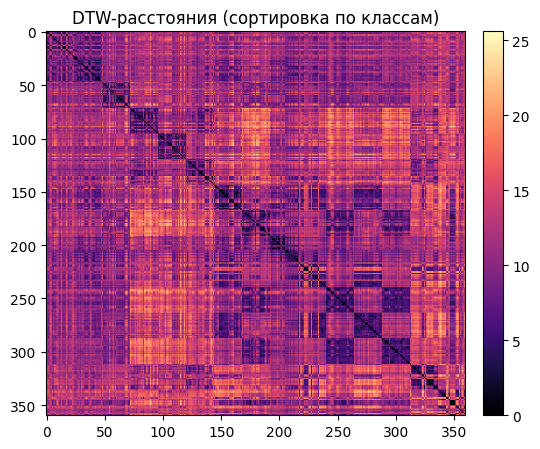

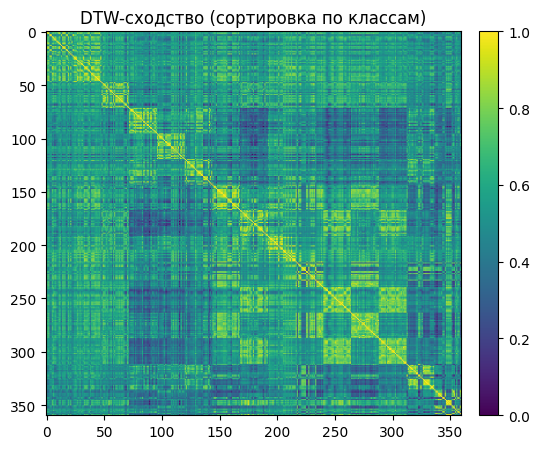

In [9]:
# Расстояния DTW и матрица сходства
start = perf_counter()
D_all_dtw = dtw_ndim.distance_matrix_fast(X_all, compact=False)
D_all_dtw = clean_square_matrix(D_all_dtw, diagonal=0.0)
print(f'Матрица расстояний DTW: shape={D_all_dtw.shape}, время={perf_counter() - start:.2f}s')

K_all_dtw = similarity_from_distance(D_all_dtw)
K_all_dtw = clean_square_matrix(K_all_dtw, diagonal=1.0)

plot_sorted_matrix(D_all_dtw, y_all, 'DTW-расстояния (сортировка по классам)', cmap='magma')
plot_sorted_matrix(K_all_dtw, y_all, 'DTW-сходство (сортировка по классам)', cmap='viridis')

После сортировки по классам видны диагональные блоки. <br>Пары из одного класса обычно ближе по DTW, но часть внедиагональных блоков сохраняется, так как некоторые жесты имеют похожие траектории.

DTW


,train_time_s,test_time_s,accuracy,f1_macro
classifier,,,,
SVC,0.0242,0.0038,0.7444,0.7387
3-NN,0.0025,0.0404,0.8333,0.8278


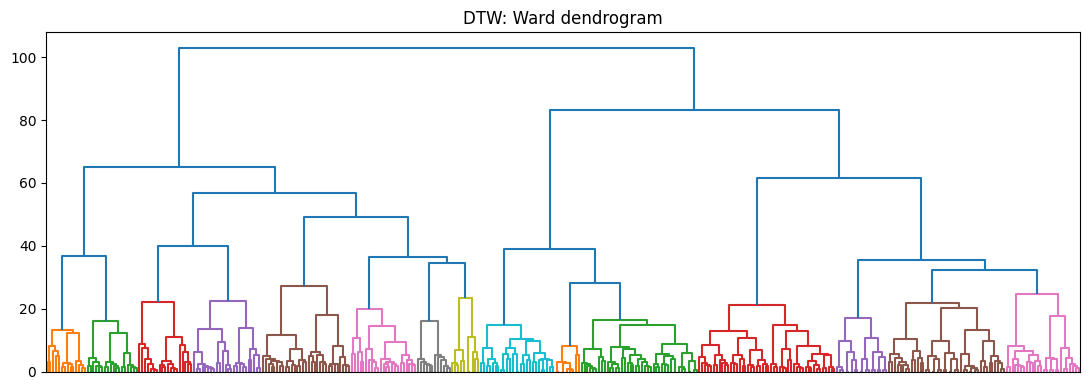

DTW: clusters=15, threshold=27.7192, NMI=0.644


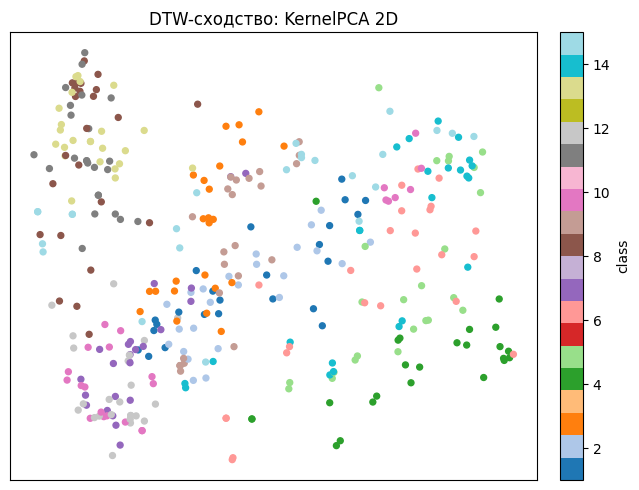

In [10]:
# Классификация, кластеризация Ward и KernelPCA
K_tr_dtw, K_te_dtw = split_train_test_matrices(K_all_dtw)
D_tr_dtw, D_te_dtw = split_train_test_matrices(D_all_dtw)

reports = {}
reports['DTW'] = evaluate_precomputed_classifiers(
    'DTW', K_tr_dtw, K_te_dtw, D_tr_dtw, D_te_dtw
)
Z_dtw, clusters_dtw, nmi_dtw = cluster_with_ward('DTW', D_all_dtw, y_all, n_classes)
coords_dtw = plot_kernel_pca('DTW-сходство', K_all_dtw, y_all)

### Упражнение 2

1. Добавьте 40% пропущенных значений к обучающим и тестовым данным.
2. Вычислите ядро TCK.
3. Вычислите матрицу различий из ядра (попробуйте сделать дополнительное к тому, что вы сделали для получения сходства из DTW).

Повторите пункты 4–7 из предыдущего упражнения.

Пропуски: train=40.2%, test=39.4%
The dataset contains missing data

Training the TCK using the following parameters:
	C = 4, G = 8
	Number of MTS for each GMM: 144 - 180 (80 - 100 percent)
	Number of attributes sampled from [2, 2]
	Length of time segments sampled from [6, 25]




Fitting GMMs:   0%|          | 0/24 [00:00<?, ?it/s]

Computing TCK (tr-tr):   0%|          | 0/24 [00:00<?, ?it/s]

Computing TCK (tr-te):   0%|          | 0/24 [00:00<?, ?it/s]

TCK-ядра train/test: Ktr=(180, 180), Kte=(180, 180), время=2.48s
The dataset contains missing data

Training the TCK using the following parameters:
	C = 4, G = 8
	Number of MTS for each GMM: 288 - 360 (80 - 100 percent)
	Number of attributes sampled from [2, 2]
	Length of time segments sampled from [6, 25]




Fitting GMMs:   0%|          | 0/24 [00:00<?, ?it/s]

Computing TCK (tr-tr):   0%|          | 0/24 [00:00<?, ?it/s]

TCK-ядро на всех данных: shape=(360, 360), время=2.13s


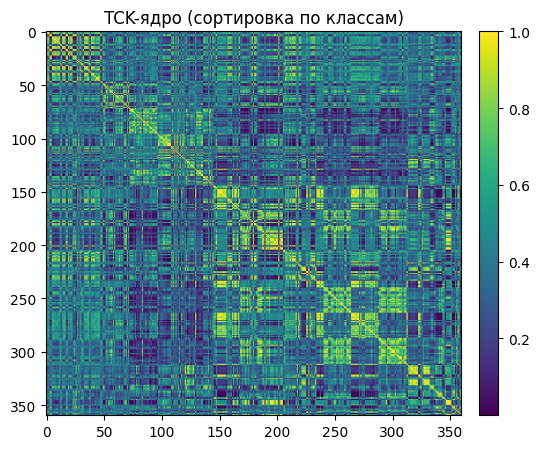

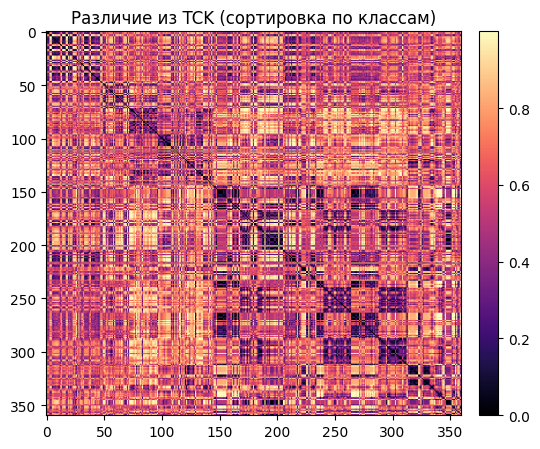

In [11]:
# 40% пропусков и ядро TCK
rng = np.random.default_rng(RANDOM_STATE)
Xtr_missing = Xtr.astype(float).copy()
Xte_missing = Xte.astype(float).copy()
Xtr_missing[rng.random(Xtr_missing.shape) < 0.40] = np.nan
Xte_missing[rng.random(Xte_missing.shape) < 0.40] = np.nan
X_all_missing = np.concatenate([Xtr_missing, Xte_missing], axis=0)

print(f'Пропуски: train={np.isnan(Xtr_missing).mean():.1%}, test={np.isnan(Xte_missing).mean():.1%}')

TCK_G = 8
TCK_C = 4

start = perf_counter()
tck_train = TCK(G=TCK_G, C=TCK_C)
K_tr_tck = tck_train.fit(Xtr_missing).predict(mode='tr-tr')
K_te_tck = tck_train.predict(mode='tr-te', Xte=Xte_missing).T
print(f'TCK-ядра train/test: Ktr={K_tr_tck.shape}, Kte={K_te_tck.shape}, время={perf_counter() - start:.2f}s')

scale_tck = max(np.nanmax(K_tr_tck), 1.0)
K_tr_tck = clean_square_matrix(K_tr_tck / scale_tck, diagonal=1.0)
K_te_tck = np.clip(K_te_tck / scale_tck, 0.0, 1.0)
D_tr_tck = clean_square_matrix(dissimilarity_from_similarity(K_tr_tck), diagonal=0.0)
D_te_tck = dissimilarity_from_similarity(K_te_tck)

start = perf_counter()
tck_all = TCK(G=TCK_G, C=TCK_C)
K_all_tck = tck_all.fit(X_all_missing).predict(mode='tr-tr')
print(f'TCK-ядро на всех данных: shape={K_all_tck.shape}, время={perf_counter() - start:.2f}s')

K_all_tck = clean_square_matrix(K_all_tck / max(np.nanmax(K_all_tck), 1.0), diagonal=1.0)
D_all_tck = clean_square_matrix(dissimilarity_from_similarity(K_all_tck), diagonal=0.0)

plot_sorted_matrix(K_all_tck, y_all, 'TCK-ядро (сортировка по классам)', cmap='viridis')
plot_sorted_matrix(D_all_tck, y_all, 'Различие из TCK (сортировка по классам)', cmap='magma')

TCK сохраняет блочную структуру даже при 40% пропусков, но границы классов становятся менее резкими, чем в чистой диагональной матрице.

TCK


,train_time_s,test_time_s,accuracy,f1_macro
classifier,,,,
SVC,0.0084,0.0018,0.4056,0.4082
3-NN,0.0010,0.0033,0.4278,0.4120


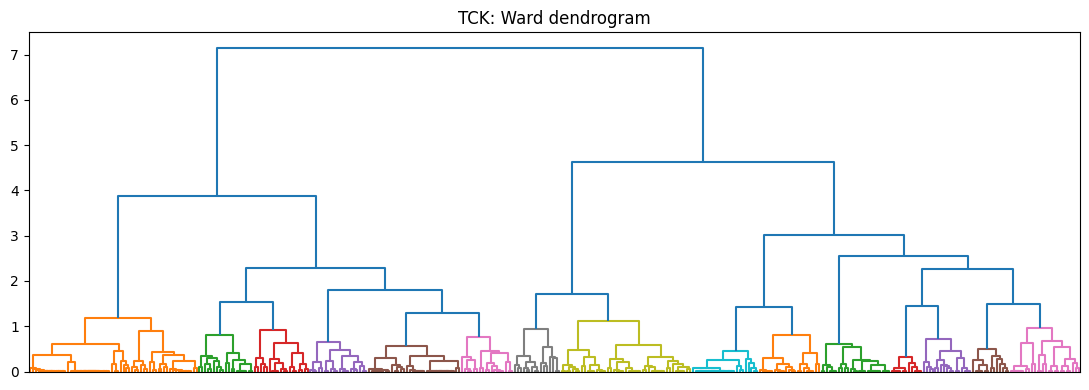

TCK: clusters=15, threshold=1.2425, NMI=0.485


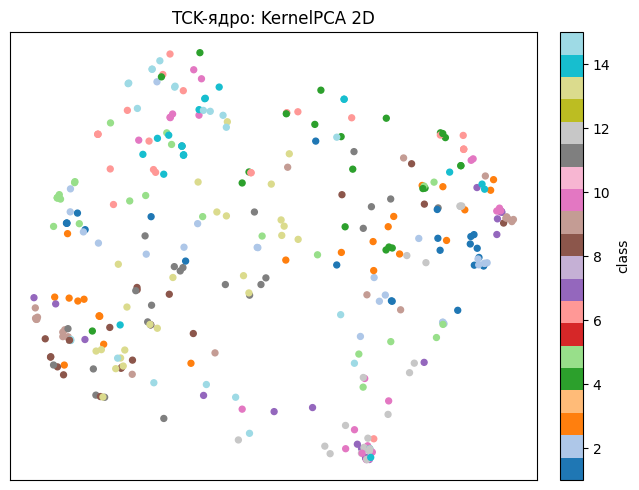

In [15]:
# Классификация, кластеризация Ward и KernelPCA
reports['TCK'] = evaluate_precomputed_classifiers(
    'TCK', K_tr_tck, K_te_tck, D_tr_tck, D_te_tck
)
Z_tck, clusters_tck, nmi_tck = cluster_with_ward('TCK', D_all_tck, y_all, n_classes)
coords_tck = plot_kernel_pca('TCK-ядро', K_all_tck, y_all)

### Упражнение 3

1. Вычислите RC-вложения.
2. Получите матрицу сходства и различия из представлений MTS.

Повторите пункты 4–7 из предыдущих упражнений.

RC-вложения: shape=(360, 600), время=2.85s


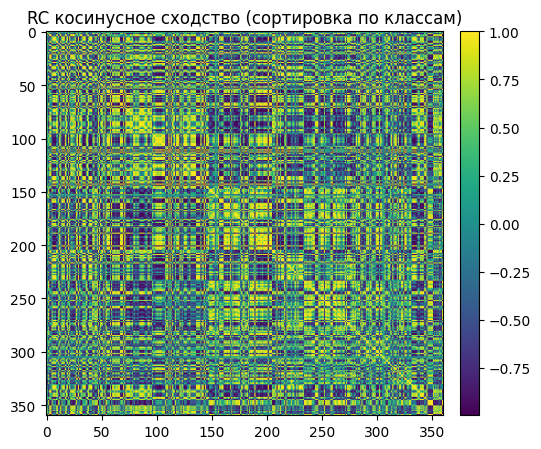

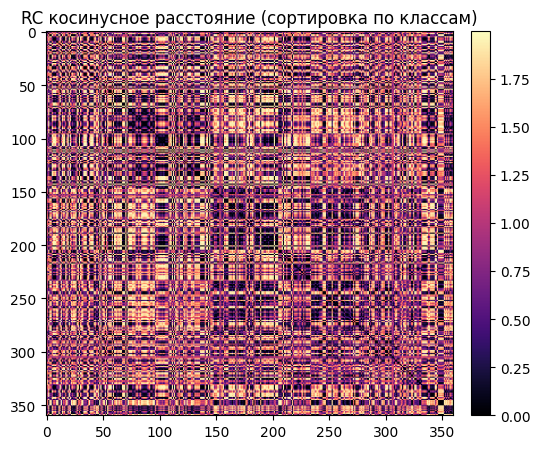

In [17]:
# RC-вложения и матрицы косинусного сходства/расстояния
np.random.seed(RANDOM_STATE)
rc_embedder = RC_model(
    n_internal_units=300,
    spectral_radius=0.9,
    leak=None,
    connectivity=0.20,
    input_scaling=0.10,
    noise_level=0.01,
    n_drop=5,
    bidir=True,
    dimred_method=None,
    mts_rep='mean',
    readout_type=None,
)

start = perf_counter()
rc_embedder.fit(X_all, verbose=False)
rc_repr = rc_embedder.input_repr
print(f'RC-вложения: shape={rc_repr.shape}, время={perf_counter() - start:.2f}s')

K_all_rc = clean_square_matrix(cosine_similarity(rc_repr), diagonal=1.0)
D_all_rc = clean_square_matrix(cosine_distances(rc_repr), diagonal=0.0)
D_all_rc = np.maximum(D_all_rc, 0.0)

plot_sorted_matrix(K_all_rc, y_all, 'RC косинусное сходство (сортировка по классам)', cmap='viridis')
plot_sorted_matrix(D_all_rc, y_all, 'RC косинусное расстояние (сортировка по классам)', cmap='magma')

RC-вложения дают более сглаженную структуру. <br>Диагональные блоки сохраняются, но косинусное расстояние сильнее смешивает похожие жесты из разных классов.

RC-вложения


,train_time_s,test_time_s,accuracy,f1_macro
classifier,,,,
SVC,0.0182,0.0060,0.2333,0.1799
3-NN,0.0080,0.0288,0.2611,0.2668


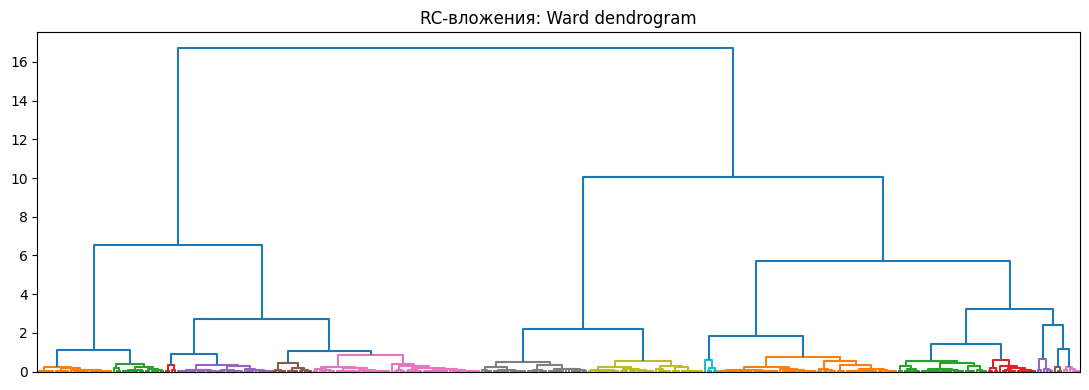

RC-вложения: clusters=15, threshold=0.8779, NMI=0.277


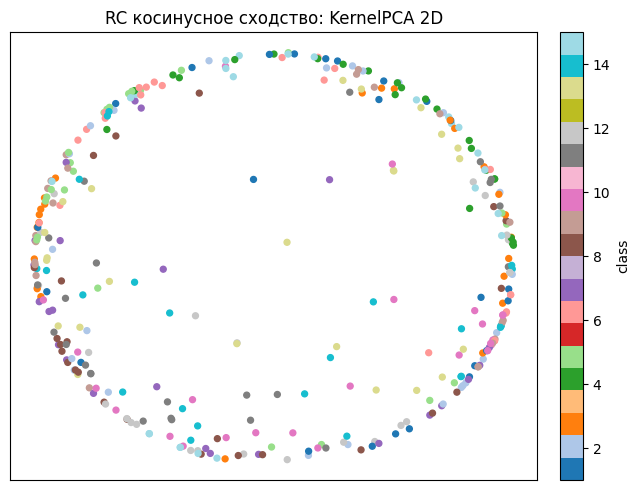

In [18]:
# Классификация, кластеризация Ward и KernelPCA
K_tr_rc, K_te_rc = split_train_test_matrices(K_all_rc)
D_tr_rc, D_te_rc = split_train_test_matrices(D_all_rc)

reports['RC'] = evaluate_precomputed_classifiers(
    'RC-вложения', K_tr_rc, K_te_rc, D_tr_rc, D_te_rc
)
Z_rc, clusters_rc, nmi_rc = cluster_with_ward('RC-вложения', D_all_rc, y_all, n_classes)
coords_rc = plot_kernel_pca('RC косинусное сходство', K_all_rc, y_all)